In [70]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition

from typing import List, Annotated

from dataclasses import dataclass
from langchain_groq import ChatGroq

from langchain_tavily import TavilySearch
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

from IPython.display import display, Image
from pprint import pprint



In [71]:
tavily_tool = TavilySearch(
    max_results=5,
    topic="general",
)

In [72]:
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=4000))

In [73]:
llm = ChatGroq(model = "qwen/qwen3-32b")
llm_bind = llm.bind_tools([tavily_tool, wiki_tool])

In [74]:
llm_bind.invoke("What is Today's News")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for "Today\'s News." I need to figure out which tool to use here. The available tools are tavily_search and wikipedia. Since the user is asking for the latest news, which is current and potentially time-sensitive, the tavily_search function seems more appropriate. The wikipedia function is better for general knowledge and factual information, not the latest news.\n\nLooking at the parameters for tavily_search, I should consider the time_range and start_date. The user wants today\'s news, so setting the time_range to "day" would limit the results to the last 24 hours. Alternatively, using the start_date as today\'s date might also work. But the time_range parameter is specifically designed for such cases. Let me check the description again. The time_range options are "day", "week", "month", "year". The description says to set this when the user explicitly mentions a time period. Since the user said "

In [75]:
@dataclass
class MyAPIBot:

    messages: Annotated[List[AnyMessage],add_messages]

In [76]:
def api_tool_llm(state: MyAPIBot):
    return {"messages":[llm_bind.invoke(state.messages)]}

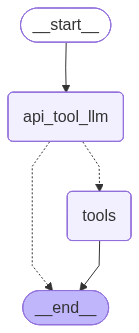

In [77]:
graph = StateGraph(MyAPIBot)

graph.add_node("api_tool_llm",api_tool_llm)
graph.add_node("tools", ToolNode([tavily_tool, wiki_tool]))


graph.add_edge(START, "api_tool_llm")
graph.add_conditional_edges("api_tool_llm",tools_condition)
graph.add_edge("tools", END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [85]:
result = graph_builder.invoke(MyAPIBot(messages=HumanMessage(content="What is Today's News related to India",name = "Kunal")))
result

{'messages': [HumanMessage(content="What is Today's News related to India", additional_kwargs={}, response_metadata={}, name='Kunal', id='4e1e2cdd-e28e-449e-af88-e69f45afd5dc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for today\'s news related to India. Let me see which tool to use. The available tools are Tavily Search and Wikipedia. Wikipedia is for general knowledge and factual information, not the latest news. So for today\'s news, I should use Tavily Search.\n\nLooking at the parameters for Tavily Search, I need to set up the query. The user wants news from India. The \'topic\' parameter has options like general, news, finance. Since it\'s about current events, setting topic to \'news\' makes sense. Also, the time_range should be \'day\' to get the latest updates from the last 24 hours. \n\nWait, the user didn\'t specify any domains to include or exclude. So include_domains and exclude_domains can stay as default. The search_depth 

In [79]:
for item in result['messages']:
    print(item.pretty_print())

================================ Human Message =================================
Name: Kunal

What is Today's News related to India
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (cypdkg0m5)
 Call ID: cypdkg0m5
  Args:
    query: India
    search_depth: advanced
    time_range: day
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.facebook.com/indiafirstunfilteredvoice/posts/unmatched-growthindia-remains-the-fastest-growing-economy-ahead-of-all-g20-natio/1396285871855507/", "title": "Unmatched Growth! India remains the Fastest Growing Economy ...", "content": "In Q4 FY25, India recorded a robust 7.4% GDP growth, bringing the full-year growth to 6.5%, more than double the global average of 3.1%. India continues to", "score": 0.5071046, "raw